<a href="https://colab.research.google.com/github/Jared2562897/Tarea-De-Modelamiento-y-Simulacion/blob/main/U3_S10_Taller_Individual_CEDE%C3%91O_VILLOTA_RICARDO_JARED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importaciones y parámetros.**

In [1]:
# -*- coding: utf-8 -*-

!pip install simpy

import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# ======================================================
# Semillas
# ======================================================

np.random.seed(30)
random.seed(30)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,5)

# ======================================================
# PARÁMETROS DEL SISTEMA (API IA)
# ======================================================

# Llegadas de usuarios (peticiones/minuto)
LAMBDA = 30

# Capacidad de cada GPU (imágenes/minuto)
MU = 10

# Número de nodos GPU
NODOS_GPU = 4

# Créditos disponibles inicialmente
CREDITOS_INICIALES = 500

# Punto de reorden
PUNTO_REORDEN = 50

# Cantidad de recarga
RECARGA_CREDITOS = 400

# Lead Time promedio (minutos)
LEAD_TIME = 2

# Tiempo total de simulación (minutos)
TIEMPO_SIMULACION = 60

**Clase APIIA.**

In [2]:
# ======================================================
# CLASE API IA
# ======================================================

class APIIA:

    def __init__(self,
                 env,
                 num_gpus,
                 creditos_iniciales,
                 punto_reorden,
                 recarga_creditos,
                 lead_time):

        self.env = env

        # Recurso: Nodos GPU
        self.gpus = simpy.Resource(env, capacity=num_gpus)

        # Inventario: Créditos disponibles
        self.creditos = simpy.Container(
            env,
            init=creditos_iniciales,
            capacity=5000
        )

        self.punto_reorden = punto_reorden
        self.recarga_creditos = recarga_creditos
        self.lead_time = lead_time

        # Estado del sistema
        self.recargas_pendientes = 0

        # Métricas
        self.tiempos_espera = []

        self.registro_creditos = []
        self.registro_tiempo = []

        self.predicciones_exitosas = 0
        self.predicciones_fallidas = 0


    # ==================================================
    # RECARGA DE CRÉDITOS
    # ==================================================

    def solicitar_recarga(self):

        self.recargas_pendientes += 1

        tiempo_real = max(
            0.1,
            random.normalvariate(self.lead_time,0.3)
        )

        yield self.env.timeout(tiempo_real)

        yield self.creditos.put(self.recarga_creditos)

        self.recargas_pendientes -= 1


    # ==================================================
    # CONTROL DEL INVENTARIO
    # ==================================================

    def controlar_creditos(self):

        while True:

            self.registro_creditos.append(
                self.creditos.level
            )

            self.registro_tiempo.append(
                self.env.now
            )

            if (
                self.creditos.level <= self.punto_reorden
                and self.recargas_pendientes == 0
            ):

                self.env.process(
                    self.solicitar_recarga()
                )

            # Revisión cada minuto
            yield self.env.timeout(1)

**Funciones peticion_api y generador_peticiones.**

In [3]:
# ======================================================
# PETICIÓN A LA API
# ======================================================

def peticion_api(env, nombre, api, mu):

    llegada = env.now

    # Solicitar un nodo GPU
    with api.gpus.request() as solicitud:

        yield solicitud

        # Tiempo de espera en cola (Wq)
        tiempo_espera = env.now - llegada
        api.tiempos_espera.append(tiempo_espera)

        # Tiempo de procesamiento de la imagen
        tiempo_servicio = random.expovariate(mu)
        yield env.timeout(tiempo_servicio)

        # Consumir un crédito de nube
        if api.creditos.level > 0:

            yield api.creditos.get(1)
            api.predicciones_exitosas += 1

        else:

            api.predicciones_fallidas += 1


# ======================================================
# GENERADOR DE PETICIONES
# ======================================================

def generador_peticiones(env, api, lam, mu):

    contador = 0

    while True:

        # Tiempo entre llegadas (Proceso de Poisson)
        tiempo_entre_llegadas = random.expovariate(lam)
        yield env.timeout(tiempo_entre_llegadas)

        contador += 1

        env.process(
            peticion_api(
                env,
                f"Petición {contador}",
                api,
                mu
            )
        )

**Ejecución de la simulación y gráficas.**

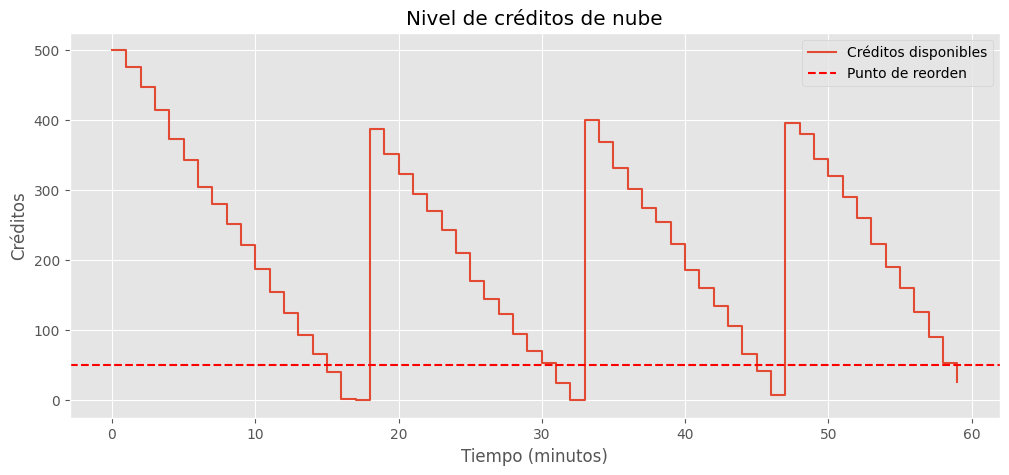

RESULTADOS DE UNA CORRIDA
Tiempo de simulación: 60 minutos
Predicciones exitosas: 1700
Predicciones fallidas: 89
Tiempo promedio en cola (Wq): 0.0487 minutos
Utilización teórica (ρ): 75.00%


In [4]:
# ======================================================
# EJECUCIÓN DE UNA SIMULACIÓN
# ======================================================

def ejecutar_simulacion_visual(tiempo_sim):

    env = simpy.Environment()

    api = APIIA(
        env,
        NODOS_GPU,
        CREDITOS_INICIALES,
        PUNTO_REORDEN,
        RECARGA_CREDITOS,
        LEAD_TIME
    )

    # Activar procesos
    env.process(
        generador_peticiones(
            env,
            api,
            LAMBDA,
            MU
        )
    )

    env.process(
        api.controlar_creditos()
    )

    # Ejecutar simulación
    env.run(until=tiempo_sim)

    # ============================================
    # GRÁFICA DEL NIVEL DE CRÉDITOS
    # ============================================

    plt.figure(figsize=(12,5))

    plt.step(
        api.registro_tiempo,
        api.registro_creditos,
        where="post",
        label="Créditos disponibles"
    )

    plt.axhline(
        y=PUNTO_REORDEN,
        color="red",
        linestyle="--",
        label="Punto de reorden"
    )

    plt.title("Nivel de créditos de nube")

    plt.xlabel("Tiempo (minutos)")
    plt.ylabel("Créditos")

    plt.legend()

    plt.show()

    # ============================================
    # RESULTADOS
    # ============================================

    if len(api.tiempos_espera) > 0:
        wq = np.mean(api.tiempos_espera)
    else:
        wq = 0

    print("==========================================")
    print("RESULTADOS DE UNA CORRIDA")
    print("==========================================")

    print(f"Tiempo de simulación: {tiempo_sim} minutos")
    print(f"Predicciones exitosas: {api.predicciones_exitosas}")
    print(f"Predicciones fallidas: {api.predicciones_fallidas}")
    print(f"Tiempo promedio en cola (Wq): {wq:.4f} minutos")

    rho = LAMBDA / (NODOS_GPU * MU)

    print(f"Utilización teórica (ρ): {rho:.2%}")


# Ejecutar una corrida

ejecutar_simulacion_visual(TIEMPO_SIMULACION)

**Evaluación de las 30 réplicas, intervalo de confianza y búsqueda automática del punto de reorden para obtener 0 predicciones fallidas.**

In [5]:
# ======================================================
# INTERVALO DE CONFIANZA
# ======================================================

def calcular_intervalo_confianza(datos, confianza=0.95):

    n = len(datos)
    media = np.mean(datos)
    error = st.sem(datos)

    h = error * st.t.ppf((1 + confianza) / 2, n - 1)

    return media, media - h, media + h


# ======================================================
# EVALUACIÓN OPERACIONAL
# ======================================================

def evaluacion_operacional(replicas, tiempo_sim, punto_reorden):

    resultados_wq = []
    resultados_fallidas = []

    for r in range(replicas):

        env = simpy.Environment()

        api = APIIA(
            env,
            NODOS_GPU,
            CREDITOS_INICIALES,
            punto_reorden,
            RECARGA_CREDITOS,
            LEAD_TIME
        )

        env.process(
            generador_peticiones(
                env,
                api,
                LAMBDA,
                MU
            )
        )

        env.process(
            api.controlar_creditos()
        )

        env.run(until=tiempo_sim)

        if len(api.tiempos_espera) > 0:
            resultados_wq.append(
                np.mean(api.tiempos_espera)
            )
        else:
            resultados_wq.append(0)

        resultados_fallidas.append(
            api.predicciones_fallidas
        )

    media, li, ls = calcular_intervalo_confianza(
        resultados_wq
    )

    promedio_fallidas = np.mean(
        resultados_fallidas
    )

    rho = LAMBDA / (NODOS_GPU * MU)

    print("\n======================================")
    print("RESULTADOS DE 30 RÉPLICAS")
    print("======================================")

    print(f"Intervalo de Confianza 95% de Wq:")
    print(f"[{li:.4f} , {ls:.4f}] minutos")

    print(f"\nPromedio de predicciones fallidas: {promedio_fallidas:.2f}")

    print(f"\nUtilización teórica (ρ): {rho:.2%}")

    return promedio_fallidas


# ======================================================
# EJECUTAR 30 RÉPLICAS
# ======================================================

evaluacion_operacional(
    replicas=30,
    tiempo_sim=TIEMPO_SIMULACION,
    punto_reorden=PUNTO_REORDEN
)


# ======================================================
# BUSCAR EL PUNTO DE REORDEN IDEAL
# ======================================================

print("\n======================================")
print("BUSCANDO PUNTO DE REORDEN ÓPTIMO")
print("======================================")

for s in range(50, 151):

    promedio = evaluacion_operacional(
        replicas=30,
        tiempo_sim=TIEMPO_SIMULACION,
        punto_reorden=s
    )

    if promedio == 0:

        print("\n======================================")
        print("SOLUCIÓN ENCONTRADA")
        print("======================================")
        print(f"Punto de reorden óptimo = {s} créditos")
        print("Predicciones fallidas = 0")
        break


RESULTADOS DE 30 RÉPLICAS
Intervalo de Confianza 95% de Wq:
[0.0442 , 0.0532] minutos

Promedio de predicciones fallidas: 92.67

Utilización teórica (ρ): 75.00%

BUSCANDO PUNTO DE REORDEN ÓPTIMO

RESULTADOS DE 30 RÉPLICAS
Intervalo de Confianza 95% de Wq:
[0.0422 , 0.0523] minutos

Promedio de predicciones fallidas: 89.43

Utilización teórica (ρ): 75.00%

RESULTADOS DE 30 RÉPLICAS
Intervalo de Confianza 95% de Wq:
[0.0473 , 0.0574] minutos

Promedio de predicciones fallidas: 89.87

Utilización teórica (ρ): 75.00%

RESULTADOS DE 30 RÉPLICAS
Intervalo de Confianza 95% de Wq:
[0.0452 , 0.0579] minutos

Promedio de predicciones fallidas: 89.27

Utilización teórica (ρ): 75.00%

RESULTADOS DE 30 RÉPLICAS
Intervalo de Confianza 95% de Wq:
[0.0476 , 0.0575] minutos

Promedio de predicciones fallidas: 81.73

Utilización teórica (ρ): 75.00%

RESULTADOS DE 30 RÉPLICAS
Intervalo de Confianza 95% de Wq:
[0.0445 , 0.0597] minutos

Promedio de predicciones fallidas: 79.10

Utilización teórica (ρ): 7

# Análisis de la utilización del hardware

La utilización teórica de los nodos GPU se calcula mediante la expresión:

- λ = 30 peticiones por minuto.
- μ = 10 imágenes procesadas por minuto por cada GPU.
- c = 4 nodos GPU.


Esto significa que las GPU trabajan aproximadamente al **75 % de su capacidad**, un nivel considerado estable ya que existe capacidad disponible para atender nuevas solicitudes sin saturar el sistema.

# ¿Por qué existen predicciones fallidas?

Aunque el hardware presenta una utilización estable (75 %), las predicciones fallidas no están relacionadas con la capacidad de procesamiento de las GPU.

El verdadero problema corresponde al inventario de créditos de nube (tokens). Cada predicción consume un crédito y, cuando el saldo disponible llega a cero, las solicitudes ya no pueden ejecutarse aunque existan GPU libres.

Durante el tiempo que tarda en llegar una nueva recarga de créditos (Lead Time de 2 minutos), continúan llegando peticiones de los usuarios. Si el inventario se agota antes de recibir la recarga, todas esas solicitudes son registradas como predicciones fallidas.

# Influencia del Lead Time

El sistema utiliza una política de inventario (s,Q), donde se solicita una nueva recarga cuando los créditos alcanzan un punto de reorden determinado.

Sin embargo, una vez enviada la solicitud de recarga, existe un retraso promedio de 2 minutos antes de que los nuevos créditos estén disponibles.

Durante ese intervalo siguen llegando aproximadamente 30 peticiones por minuto, por lo que pueden consumirse cerca de 60 créditos antes de recibir la recarga.

Si el punto de reorden es demasiado bajo, el inventario disponible no alcanza para cubrir la demanda durante ese tiempo de espera, provocando predicciones fallidas.

# Conclusión

Los resultados muestran que el cuello de botella del sistema no corresponde a la infraestructura de procesamiento, sino a la política de administración de créditos.

Las GPU mantienen una utilización adecuada (ρ = 75 %), lo que indica que existe capacidad suficiente para atender las solicitudes.

Las predicciones fallidas aparecen únicamente porque el punto de reorden inicial no garantiza suficientes créditos durante el Lead Time de recarga.

Al incrementar el punto de reorden hasta un valor que cubra completamente el consumo esperado durante ese tiempo, el inventario nunca llega a cero y las predicciones fallidas desaparecen, manteniendo al mismo tiempo una utilización estable del hardware.